In [15]:
import pandas as pd
import glob

dfs = [pd.read_csv(f) for f in sorted(glob.glob('data/results_logprobs_lemonde_macron*.csv'))]
df = pd.concat(dfs, ignore_index=True)
df.head()

,model,prompt_variant,article,question,quadrant,quadrant_label,answerable,mean_logprob,answer,abstained,human_score
0,Qwen/Qwen3-4B,explicit_abstain,macron_africa_forward_lemonde_12mai2026.txt,Quel est le montant de l'accord signé par CMA ...,A,précis + adapté,True,-0.0019,Le montant de l'accord signé par CMA CGM au so...,False,NaN
1,Qwen/Qwen3-4B,explicit_abstain,macron_africa_forward_lemonde_12mai2026.txt,Quel est le montant total des investissements ...,A,précis + adapté,True,-0.0167,Le montant total des investissements français ...,False,NaN
2,Qwen/Qwen3-4B,explicit_abstain,macron_africa_forward_lemonde_12mai2026.txt,Quel est le montant total des investissements ...,A,précis + adapté,True,-0.0095,"Selon l'article, le montant total des investis...",False,NaN
3,Qwen/Qwen3-4B,explicit_abstain,macron_africa_forward_lemonde_12mai2026.txt,Combien de chefs d'entreprise ont participé au...,A,précis + adapté,True,-0.0539,"Selon l'article, 1 500 chefs d'entreprises ont...",False,NaN
4,Qwen/Qwen3-4B,explicit_abstain,macron_africa_forward_lemonde_12mai2026.txt,Quand Donald Trump a-t-il fermé l'agence d'aid...,A,précis + adapté,True,-0.0000,Donald Trump a fermé l'agence d'aide au dévelo...,False,NaN


In [16]:
MODEL_LABELS = {
    "Qwen/Qwen3-4B":                  "Qwen3-4B",
    "Qwen/Qwen3.5-0.8B":              "Qwen3.5-0.8B",
    "Qwen/Qwen3.5-2B":                "Qwen3.5-2B",
    "Qwen/Qwen3.5-4B":                "Qwen3.5-4B",
    "Qwen/Qwen3.6-27B-FP8":           "Qwen3.6-27B",
    "RedHatAI/Qwen3.6-35B-A3B-NVFP4": "Qwen3.6-35B",
}

df["model_short"] = df["model"].map(MODEL_LABELS).fillna(df["model"])
df["model_short"].value_counts()

model_short
Qwen3-4B        38
Qwen3.5-0.8B    38
Qwen3.5-2B      38
Qwen3.5-4B      38
Qwen3.6-27B     38
Qwen3.6-35B     38
Name: count, dtype: int64

In [17]:
df.groupby(['model', 'prompt_variant', 'quadrant'])['mean_logprob'].mean().unstack('quadrant')

quadrant                                                A         B         C  \
model                          prompt_variant                                   
Qwen/Qwen3-4B                  explicit_abstain -0.013012  0.000000 -0.093575   
                               free             -0.026175 -0.058833 -0.091325   
Qwen/Qwen3.5-0.8B              explicit_abstain -0.193387 -0.096567 -0.498175   
                               free             -0.276663 -0.547067 -0.500225   
Qwen/Qwen3.5-2B                explicit_abstain -0.135950 -0.020167 -0.274025   
                               free             -0.165550 -0.269033 -0.310775   
Qwen/Qwen3.5-4B                explicit_abstain -0.083950 -0.014467 -0.159150   
                               free             -0.119000 -0.178200 -0.236975   
Qwen/Qwen3.6-27B-FP8           explicit_abstain -0.080525 -0.000067 -0.071425   
                               free             -0.060100 -0.131633 -0.099575   
RedHatAI/Qwen3.6-35B-A3B-NVFP4 explicit_abstain -0.057325 -0.000200 -0.097350   
                               free             -0.068837 -0.111200 -0.108475   

quadrant                                                D  
model                          prompt_variant              
Qwen/Qwen3-4B                  explicit_abstain -0.038975  
                               free             -0.136450  
Qwen/Qwen3.5-0.8B              explicit_abstain -0.429100  
                               free             -0.548625  
Qwen/Qwen3.5-2B                explicit_abstain -0.134400  
                               free             -0.370950  
Qwen/Qwen3.5-4B                explicit_abstain -0.024900  
                               free             -0.294175  
Qwen/Qwen3.6-27B-FP8           explicit_abstain -0.008650  
                               free             -0.134350  
RedHatAI/Qwen3.6-35B-A3B-NVFP4 explicit_abstain -0.000925  
                               free             -0.171350

In [18]:
df.groupby(['model', 'prompt_variant', 'quadrant'])['abstained'].mean().unstack('quadrant')

quadrant                                             A    B    C     D
model                          prompt_variant                         
Qwen/Qwen3-4B                  explicit_abstain  0.125  1.0  0.0  0.75
                               free              0.000  0.0  0.0  0.00
Qwen/Qwen3.5-0.8B              explicit_abstain  0.125  1.0  0.0  0.50
                               free              0.000  0.0  0.0  0.00
Qwen/Qwen3.5-2B                explicit_abstain  0.125  1.0  0.0  1.00
                               free              0.000  0.0  0.0  0.00
Qwen/Qwen3.5-4B                explicit_abstain  0.250  1.0  0.0  1.00
                               free              0.000  0.0  0.0  0.00
Qwen/Qwen3.6-27B-FP8           explicit_abstain  0.125  1.0  0.0  1.00
                               free              0.000  0.0  0.0  0.00
RedHatAI/Qwen3.6-35B-A3B-NVFP4 explicit_abstain  0.125  1.0  0.0  1.00
                               free              0.000  0.0  0.0  0.00

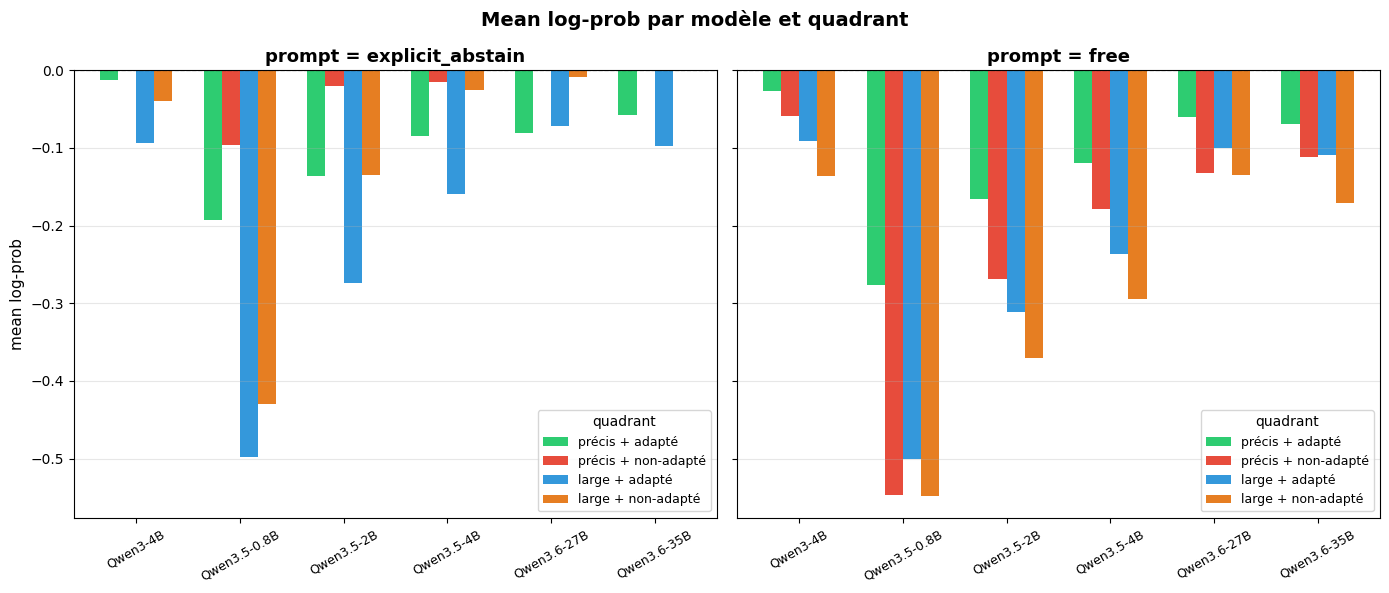

In [19]:
import matplotlib.pyplot as plt

variants = sorted(df["prompt_variant"].unique())
fig, axes = plt.subplots(1, len(variants), figsize=(7 * len(variants), 6), sharey=True)
if len(variants) == 1:
    axes = [axes]

QUADRANT_LABELS = {
    "A": "précis + adapté",
    "B": "précis + non-adapté",
    "C": "large + adapté",
    "D": "large + non-adapté",
}
QUADRANT_COLORS = {
    "A": "#2ecc71",
    "B": "#e74c3c",
    "C": "#3498db",
    "D": "#e67e22",
}

for ax, variant in zip(axes, variants):
    grp = df[df["prompt_variant"] == variant]
    pivot = grp.groupby(["model_short", "quadrant"])["mean_logprob"].mean().unstack("quadrant")
    pivot = pivot.sort_index()
    colors = [QUADRANT_COLORS.get(c, "grey") for c in pivot.columns]
    pivot = pivot.rename(columns=QUADRANT_LABELS)
    pivot.plot(kind="bar", ax=ax, rot=30, color=colors, width=0.7)
    ax.set_title(f"prompt = {variant}", fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("mean log-prob", fontsize=11)
    ax.tick_params(axis="x", labelsize=9)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.legend(title="quadrant", fontsize=9)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Mean log-prob par modèle et quadrant", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


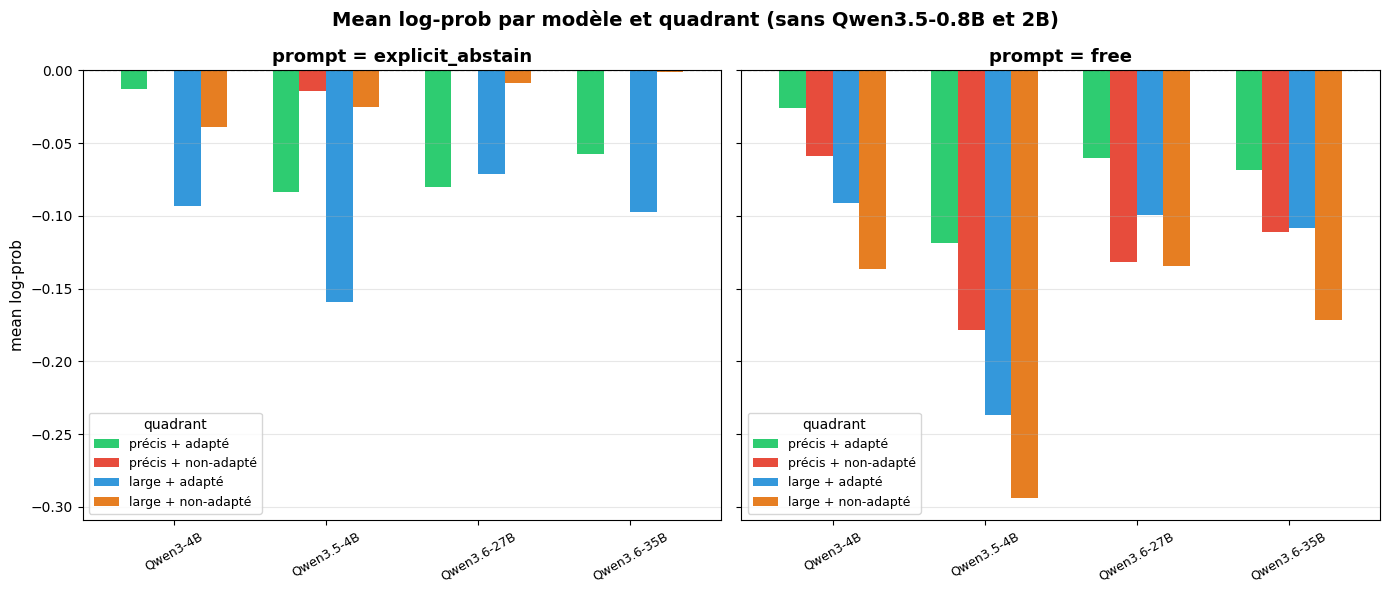

In [ ]:
import matplotlib.pyplot as plt
df_filtered = df[~df["model_short"].isin(["Qwen3.5-0.8B", "Qwen3.5-2B"])]
variants = sorted(df_filtered["prompt_variant"].unique())
fig, axes = plt.subplots(1, len(variants), figsize=(7 * len(variants), 6), sharey=True)
if len(variants) == 1:
    axes = [axes]

QUADRANT_LABELS = {
    "A": "précis + adapté",
    "B": "précis + non-adapté",
    "C": "large  + adapté",
    "D": "large  + non-adapté",
}
QUADRANT_COLORS = {
    "A": "#2ecc71",
    "B": "#e74c3c",
    "C": "#3498db",
    "D": "#e67e22",
}

for ax, variant in zip(axes, variants):
    grp = df_filtered[df_filtered["prompt_variant"] == variant]
    pivot = grp.groupby(["model_short", "quadrant"])["mean_logprob"].mean().unstack("quadrant")
    pivot = pivot.sort_index()
    colors = [QUADRANT_COLORS.get(c, "grey") for c in pivot.columns]
    pivot = pivot.rename(columns=QUADRANT_LABELS)
    pivot.plot(kind="bar", ax=ax, rot=30, color=colors, width=0.7)
    ax.set_title(f"prompt = {variant}", fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("mean log-prob", fontsize=11)
    ax.tick_params(axis="x", labelsize=9)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.legend(title="quadrant", fontsize=9)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Mean log-prob par modèle et quadrant (sans Qwen3.5-0.8B et 2B)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [21]:
cols = ['model', 'prompt_variant', 'quadrant', 'answerable', 'mean_logprob', 'abstained', 'question', 'answer']
df[cols].sort_values(['model', 'prompt_variant', 'quadrant'])

,model,prompt_variant,quadrant,answerable,mean_logprob,abstained,question,answer
0,Qwen/Qwen3-4B,explicit_abstain,A,True,-0.0019,False,Quel est le montant de l'accord signé par CMA ...,Le montant de l'accord signé par CMA CGM au so...
1,Qwen/Qwen3-4B,explicit_abstain,A,True,-0.0167,False,Quel est le montant total des investissements ...,Le montant total des investissements français ...
2,Qwen/Qwen3-4B,explicit_abstain,A,True,-0.0095,False,Quel est le montant total des investissements ...,"Selon l'article, le montant total des investis..."
3,Qwen/Qwen3-4B,explicit_abstain,A,True,-0.0539,False,Combien de chefs d'entreprise ont participé au...,"Selon l'article, 1 500 chefs d'entreprises ont..."
4,Qwen/Qwen3-4B,explicit_abstain,A,True,-0.0000,False,Quand Donald Trump a-t-il fermé l'agence d'aid...,Donald Trump a fermé l'agence d'aide au dévelo...
...,...,...,...,...,...,...,...,...
220,RedHatAI/Qwen3.6-35B-A3B-NVFP4,free,C,True,-0.0377,False,Quelle est la position de Macron sur la représ...,"Selon l'article, Emmanuel Macron a promis que ..."
224,RedHatAI/Qwen3.6-35B-A3B-NVFP4,free,D,False,-0.1606,False,Quelle est la situation politique générale en ...,"D'après le texte fourni, la situation politiqu..."
225,RedHatAI/Qwen3.6-35B-A3B-NVFP4,free,D,False,-0.1572,False,Comment fonctionne le mécanisme d'aide au déve...,"D'après le document fourni, il n'est pas possi..."
226,RedHatAI/Qwen3.6-35B-A3B-NVFP4,free,D,False,-0.1807,False,Quelles sont les causes profondes de l'influen...,"D'après le texte fourni, il n'est pas possible..."
